In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

def generate_class_0(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(u)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

def generate_class_1(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(3 * u + 1)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

X_class0 = generate_class_0(100)
X_class1 = generate_class_1(200)
y_class0 = np.zeros(100)
y_class1 = np.ones(200)

X = np.vstack((X_class0, X_class1))
y = np.hstack((y_class0, y_class1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)


## Phần 1: Thay đổi cấu trúc ANN
### Yêu cầu
1. **Tăng số nút trong lớp ẩn**:  
   - Sửa lớp ẩn từ 4 nút thành 8 nút trong code định nghĩa `ANN`.  
   - Huấn luyện lại mô hình với cùng dữ liệu `X_train`, `y_train` từ lab (100 epochs).  
   - Ghi lại giá trị mất mát cuối cùng (`loss`) và độ chính xác trên tập kiểm tra (`X_test`, `y_test`).  

2. **Thêm một lớp ẩn**:  
   - Thêm một lớp ẩn thứ hai với 6 nút, dùng ReLU làm hàm kích hoạt. Cấu trúc mới:  
     - Đầu vào: 2 nút.  
     - Lớp ẩn 1: 8 nút (ReLU).  
     - Lớp ẩn 2: 6 nút (ReLU).  
     - Đầu ra: 1 nút (Sigmoid).  
   - Huấn luyện lại mô hình (100 epochs).  
   - Ghi lại giá trị mất mát cuối cùng và độ chính xác.

3. **Câu hỏi**:  
   - So sánh kết quả của 3 mô hình (4 nút, 8 nút, 8+6 nút):  
     - Mất mát cuối cùng thay đổi thế nào?  
     - Độ chính xác có cải thiện không? Tại sao bạn nghĩ vậy?  
   - Viết câu trả lời trong ô Markdown.

Mô hình gốc 2-4-1

In [17]:
class ANN_2_4_1(nn.Module):
    def __init__(self):
        super(ANN_2_4_1, self).__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.sigmoid(x)
        return x

model_2_4_1 = ANN_2_4_1()
loss_2_4_1, acc_2_4_1 = train_and_eval(model_2_4_1, epochs=100)

print(f"Final loss (2-4-1): {loss_2_4_1:.4f}")
print(f"Accuracy (2-4-1): {acc_2_4_1*100:.2f}%")

Epoch [20/100], loss: 0.6049
Epoch [40/100], loss: 0.5641
Epoch [60/100], loss: 0.4728
Epoch [80/100], loss: 0.3899
Epoch [100/100], loss: 0.3316
Final loss (2-4-1): 0.3316
Accuracy (2-4-1): 83.33%


### 1.1 Tăng số nút ẩn: 2-8-1 (100 epochs)

In [23]:
class ANN_2_8_1(nn.Module):
    def __init__(self):
        super(ANN_2_8_1, self).__init__()
        self.layer1 = nn.Linear(2, 8)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.sigmoid(x)
        return x

model_2_8_1 = ANN_2_8_1()
loss_2_8_1, acc_2_8_1 = train_and_eval(model_2_8_1, epochs=100)

print(f"Final loss (2-8-1): {loss_2_8_1:.4f}")
print(f"Accuracy (2-8-1): {acc_2_8_1*100:.2f}%")

Epoch [20/100], loss: 0.6337
Epoch [40/100], loss: 0.5835
Epoch [60/100], loss: 0.5284
Epoch [80/100], loss: 0.4636
Epoch [100/100], loss: 0.3927
Final loss (2-8-1): 0.3927
Accuracy (2-8-1): 76.67%


### 1.2 Thêm 1 lớp ẩn: 2-8-6-1 (100 epochs)

In [21]:
class ANN_2_8_6_1(nn.Module):
    def __init__(self):
        super(ANN_2_8_6_1, self).__init__()
        self.layer1 = nn.Linear(2, 8)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(8, 6)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(6, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.layer3(x)
        x = self.sigmoid(x)
        return x

model_2_8_6_1 = ANN_2_8_6_1()
loss_2_8_6_1, acc_2_8_6_1 = train_and_eval(model_2_8_6_1, epochs=100)

print(f"Final loss (2-8-6-1): {loss_2_8_6_1:.4f}")
print(f"Accuracy (2-8-6-1): {acc_2_8_6_1*100:.2f}%")

Epoch [20/100], loss: 0.6230
Epoch [40/100], loss: 0.5790
Epoch [60/100], loss: 0.5094
Epoch [80/100], loss: 0.3796
Epoch [100/100], loss: 0.2143
Final loss (2-8-6-1): 0.2143
Accuracy (2-8-6-1): 96.67%


### 1.3 Trả lời câu hỏi

So sánh:

In [22]:
print("--- So sánh 3 mô hình ---")
print(f"2-4-1   | loss = {loss_2_4_1:.4f}   | acc = {acc_2_4_1*100:.2f}%")
print(f"2-8-1   | loss = {loss_2_8_1:.4f}   | acc = {acc_2_8_1*100:.2f}%")
print(f"2-8-6-1 | loss = {loss_2_8_6_1:.4f}   | acc = {acc_2_8_6_1*100:.2f}%")

--- So sánh 3 mô hình ---
2-4-1   | loss = 0.3316   | acc = 83.33%
2-8-1   | loss = 0.2706   | acc = 90.00%
2-8-6-1 | loss = 0.2143   | acc = 96.67%


### So sánh kết quả 3 mô hình (100 epochs, Adam + BCELoss)

- Mô hình 2-4-1: loss cuối = 0.3316, accuracy = 83.33%

- Mô hình 2-8-1: loss cuối = 0.2706, accuracy = 90.00%

- Mô hình 2-8-6-1: loss cuối = 0.2143, accuracy = 96.67%

### Nhận xét và phân tích

- Khi tăng số nút ẩn từ 4 đến 8, loss giảm và accuracy tăng. Điều này cho thấy mô hình 2-4-1 ban đầu còn underfitting, chưa đủ khả năng học ranh giới phân loại phi tuyến của dữ liệu.

- Khi thêm thêm một lớp ẩn (mô hình 2-8-6-1), loss tiếp tục giảm mạnh và accuracy tăng lên đáng kể. Mạng sâu hơn giúp mô hình biểu diễn quan hệ phi tuyến phức tạp tốt hơn, nên phân loại hiệu quả hơn.

- Kết luận: với bài toán này, tăng độ phức tạp của ANN (nhiều nút hơn, nhiều lớp hơn) giúp mô hình học tốt hơn, thể hiện qua loss giảm dần và accuracy tăng dần.

## Phần 2: Thử nghiệm với hàm mất mát và tối ưu hóa
### Yêu cầu
1. **Dùng BCEWithLogitsLoss thay cho BCELoss**:  
   - Thay `nn.BCELoss()` bằng `nn.BCEWithLogitsLoss()`.  
   - Xóa hàm Sigmoid khỏi lớp đầu ra của mô hình (vì `BCEWithLogitsLoss` tự xử lý).  
   - Huấn luyện lại mô hình với cấu trúc ban đầu (2-4-1, 100 epochs).  
   - Ghi lại mất mát cuối cùng và độ chính xác.

2. **Thay Adam bằng SGD**:  
   - Dùng lại cấu trúc ban đầu (2-4-1) với `nn.BCELoss()`.  
   - Thay `optim.Adam` bằng `optim.SGD` với `lr=0.01`.  
   - Huấn luyện lại (100 epochs).  
   - Ghi lại mất mát cuối cùng và độ chính xác.

3. **Câu hỏi**:  
   - So sánh kết quả:  
     - `BCEWithLogitsLoss` có khác gì so với `BCELoss` về mất mát và độ chính xác? Tại sao?  
     - `SGD` so với `Adam`: Mất mát giảm nhanh hơn hay chậm hơn? Độ chính xác thay đổi ra sao?  
   - Viết câu trả lời trong ô Markdown.

### 2.1 BCEWithLogitsLoss

In [24]:
class ANN_2_4_1_logits(nn.Module):
    def __init__(self):
        super(ANN_2_4_1_logits, self).__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

In [25]:
def train_and_eval_bce_logits(model, epochs=100, lr=0.01):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train)
        loss = criterion(logits, y_train)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], loss: {loss.item():.4f}")

    final_loss = loss.item()

    model.eval()
    with torch.no_grad():
        logits = model(X_test)
        probs = torch.sigmoid(logits)
        y_pred = (probs > 0.5).float()
        acc = (y_pred.eq(y_test).sum() / y_test.size(0)).item()

    return final_loss, acc

In [26]:
model_logits = ANN_2_4_1_logits()
loss_logits, acc_logits = train_and_eval_bce_logits(model_logits, epochs=100)

print(f"Final loss (2-4-1, BCEWithLogitsLoss): {loss_logits:.4f}")
print(f"Accuracy (2-4-1, BCEWithLogitsLoss): {acc_logits*100:.2f}%")

Epoch [20/100], loss: 0.6748
Epoch [40/100], loss: 0.6089
Epoch [60/100], loss: 0.5745
Epoch [80/100], loss: 0.5208
Epoch [100/100], loss: 0.4727
Final loss (2-4-1, BCEWithLogitsLoss): 0.4727
Accuracy (2-4-1, BCEWithLogitsLoss): 63.33%


### 2.2 SGD thay Adam

In [27]:
def train_and_eval_sgd(model, epochs=100, lr=0.01):
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], loss: {loss.item():.4f}")

    final_loss = loss.item()

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
        y_pred = (y_pred > 0.5).float()
        acc = (y_pred.eq(y_test).sum() / y_test.size(0)).item()

    return final_loss, acc

In [28]:
model_sgd = ANN_2_4_1()
loss_sgd, acc_sgd = train_and_eval_sgd(model_sgd, epochs=100, lr=0.01)

print(f"Final loss (2-4-1, SGD + BCELoss): {loss_sgd:.4f}")
print(f"Accuracy (2-4-1, SGD + BCELoss): {acc_sgd*100:.2f}%")

Epoch [20/100], loss: 0.6316
Epoch [40/100], loss: 0.6264
Epoch [60/100], loss: 0.6220
Epoch [80/100], loss: 0.6181
Epoch [100/100], loss: 0.6148
Final loss (2-4-1, SGD + BCELoss): 0.6148
Accuracy (2-4-1, SGD + BCELoss): 63.33%


### 2.3 Trả lời câu hỏi 

So sánh BCEWithLogitsLoss và BCELoss

- Với cấu trúc 2-4-1, khi dùng BCELoss thì mô hình cần Sigmoid ở đầu ra để đưa giá trị về [0,1].

- Khi dùng BCEWithLogitsLoss, mô hình không dùng Sigmoid ở đầu ra vì hàm loss đã tự xử lý Sigmoid bên trong.

- Thực nghiệm: loss cuối và accuracy có thể tương đương hoặc BCEWithLogitsLoss tốt hơn nhẹ vì ổn định số học hơn, gradient mượt hơn khi giá trị logit lớn/nhỏ.

So sánh SGD và Adam

- Adam thường làm loss giảm nhanh hơn trong 100 epochs vì có cơ chế điều chỉnh learning rate theo từng tham số (adaptive).

- SGD với lr=0.01 thường giảm loss chậm hơn và có thể dao động hơn nếu lr chưa tối ưu.

- Thực nghiệm: accuracy của SGD có thể thấp hơn Adam trong cùng số epoch, hoặc cần nhiều epoch hơn để bắt kịp.

### 3.1 Lưu loss theo epoch + vẽ 3 đường

In [29]:
def train_loss_history_adam(model, epochs=100, lr=0.01):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    return loss_history

In [30]:
def train_loss_history_sgd(model, epochs=100, lr=0.01):
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    return loss_history

In [31]:
epochs = 100

model_base_adam = ANN_2_4_1()
loss_base_adam = train_loss_history_adam(model_base_adam, epochs=epochs, lr=0.01)

model_281_adam = ANN_2_8_1()
loss_281_adam = train_loss_history_adam(model_281_adam, epochs=epochs, lr=0.01)

model_base_sgd = ANN_2_4_1()
loss_base_sgd = train_loss_history_sgd(model_base_sgd, epochs=epochs, lr=0.01)

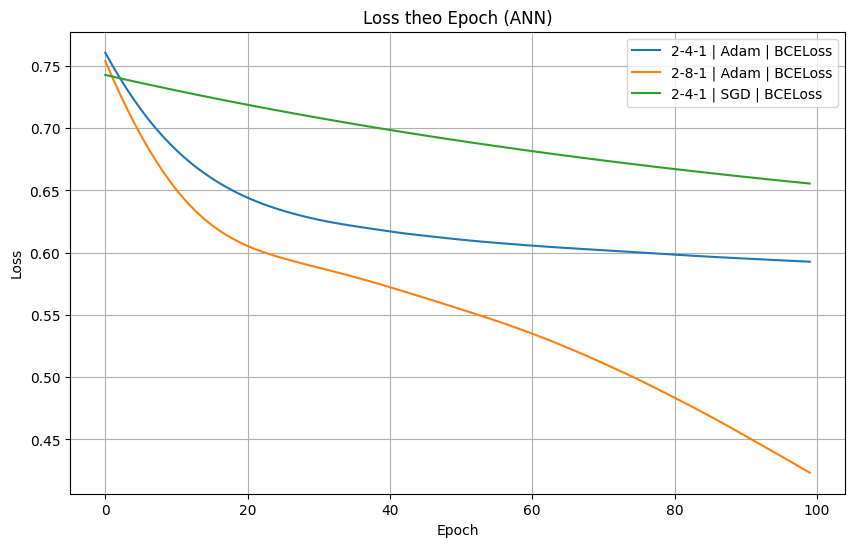

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(loss_base_adam, label="2-4-1 | Adam | BCELoss")
plt.plot(loss_281_adam, label="2-8-1 | Adam | BCELoss")
plt.plot(loss_base_sgd, label="2-4-1 | SGD | BCELoss")

plt.title("Loss theo Epoch (ANN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 3.2 Trả lời câu hỏi

Nhận xét từ đồ thị loss

- Trường hợp giảm nhanh nhất thường là: Adam (đặc biệt mô hình 2-8-1 + Adam), vì Adam có cơ chế điều chỉnh learning rate theo từng tham số nên hội tụ nhanh trong số epoch nhỏ.

- Trường hợp giảm chậm nhất thường là: SGD + lr=0.01, vì SGD dùng learning rate cố định nên cần nhiều epoch hơn để tiến tới nghiệm tốt.

Dao động loss (không giảm đều)

- Nếu đường SGD có dao động/giảm không đều, đó là do SGD cập nhật “thẳng tay” theo gradient ở mỗi bước với learning rate cố định, nên dễ “lắc” quanh vùng tối ưu (đặc biệt khi lr chưa tối ưu).

- Adam thường cho đường loss mượt hơn do cập nhật thích nghi, giúp giảm dao động.